# Train LSTM (5-Fold CV)
Loads `X_3D.npy` and trains LSTM using 5-Fold Cross Validation.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Conv1D, MaxPooling1D, Dropout


In [2]:
X_train = np.load('../dataset/X_train_3D.npy')
y_train = np.load('../dataset/y_train.npy')
X_test = np.load('../dataset/X_test_3D.npy')
y_test = np.load('../dataset/y_test.npy')
print('X_train shape:', X_train.shape, 'X_test shape:', X_test.shape)


X_train shape: (46606, 5, 28) X_test shape: (10027, 5, 28)


In [3]:
# Custom Callback for Epoch Milestones
class MilestoneLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.start_time = time.time()
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            elapsed = time.time() - self.start_time
            print(f"\n--- Epoch {epoch + 1} Milestone ---")
            print(f"Time Elapsed: {elapsed:.2f}s")
            print(f"Loss: {logs.get('loss'):.4f} - Accuracy: {logs.get('accuracy'):.4f}")
            print(f"Val Loss: {logs.get('val_loss'):.4f} - Val Accuracy: {logs.get('val_accuracy'):.4f}\n")

In [4]:
def create_model():
    model = Sequential([
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [5]:
start_time = time.time()

# Chronological train/val split (90% train, 10% val)
n = len(X_train)
split_idx = int(n * 0.9)
X_train_sub, X_val = X_train[:split_idx], X_train[split_idx:]
y_train_sub, y_val = y_train[:split_idx], y_train[split_idx:]

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

model = create_model()
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

history = model.fit(
    X_train_sub, y_train_sub,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, MilestoneLogger()],
    verbose=1
)

end_time = time.time()
print(f"\nTraining Time: {end_time - start_time:.2f} seconds")


Epoch 1/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8735 - loss: 0.3635 - val_accuracy: 0.8745 - val_loss: 0.3075
Epoch 2/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8918 - loss: 0.3161 - val_accuracy: 0.8303 - val_loss: 0.3691
Epoch 3/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8930 - loss: 0.3077 - val_accuracy: 0.7711 - val_loss: 0.4269
Epoch 4/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8931 - loss: 0.3038 - val_accuracy: 0.8451 - val_loss: 0.3348
Epoch 5/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8931 - loss: 0.3007 - val_accuracy: 0.8749 - val_loss: 0.3049
Epoch 6/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8937 - loss: 0.2991 - val_accuracy: 0.8258 - val_loss: 0.3724
Epoch 7/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8945 - loss: 0.2949 - val_accuracy: 0.8262 - val_loss: 0.3797
Epoch 8/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8933 - loss: 0.2946 - val_accuracy: 0.

Test Accuracy: 86.72%

Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1302
           1       0.96      0.91      0.93      7610
           2       0.47      0.74      0.58      1115

    accuracy                           0.87     10027
   macro avg       0.78      0.79      0.77     10027
weighted avg       0.90      0.87      0.88     10027



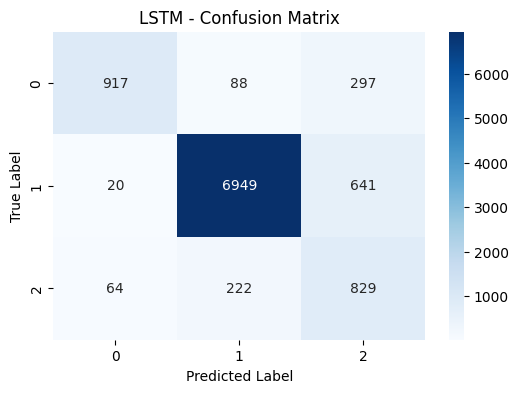

Model saved successfully!


In [6]:
from sklearn.metrics import accuracy_score
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print('\nTest Classification Report:')
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LSTM - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
model.save('../models/lstm_model.keras')
print('Model saved successfully!')

# Controlled Epoch Evaluation Experiment
*(Added automatically per rigorous experiment protocol)*

In [7]:
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, recall_score, log_loss
import tensorflow as tf
import os

# Reproducibility Seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Loading Data and Splitting Chronologically per Feeder...")
X_train_unscaled = np.load('../dataset/X_train.npy')
y_train_full = np.load('../dataset/y_train_full.npy')
X_train_scaled = np.load('../dataset/X_train_scaled.npy')

sub_col = 13
fdr_col = 14
TIME_STEPS = 5

train_seq_X, train_seq_y = [], []
val_seq_X, val_seq_y = [], []

unique_feeders = np.unique(X_train_unscaled[:, [sub_col, fdr_col]], axis=0)

for feeder in unique_feeders:
    mask = (X_train_unscaled[:, sub_col] == feeder[0]) & (X_train_unscaled[:, fdr_col] == feeder[1])
    idx = np.where(mask)[0]
    
    n = len(idx)
    split_idx = int(n * 0.8)
    
    train_idx = idx[:split_idx]
    val_idx = idx[split_idx:]
    
    for i in range(len(train_idx) - TIME_STEPS):
        train_seq_X.append(X_train_scaled[train_idx[i : i + TIME_STEPS]])
        train_seq_y.append(y_train_full[train_idx[i + TIME_STEPS]])
        
    for i in range(len(val_idx) - TIME_STEPS):
        val_seq_X.append(X_train_scaled[val_idx[i : i + TIME_STEPS]])
        val_seq_y.append(y_train_full[val_idx[i + TIME_STEPS]])

X_train_3D = np.array(train_seq_X)
y_train_seq = np.array(train_seq_y)
X_val_3D = np.array(val_seq_X)
y_val_seq = np.array(val_seq_y)

X_test_3D = np.load('../dataset/X_test_3D.npy')
y_test_seq = np.load('../dataset/y_test.npy')

c_in = X_train_3D.shape[2]
seq_len = X_train_3D.shape[1]
c_out = 3

Loading Data and Splitting Chronologically per Feeder...


In [8]:
def calculate_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    high_risk_recall = recall_score(y_true, y_pred, labels=[2], average='macro')
    if np.isnan(high_risk_recall): high_risk_recall = 0.0
    loss = log_loss(y_true, y_prob) if y_prob is not None else 0.0
    return acc, macro_f1, high_risk_recall, loss

results = []
EPOCHS = 50
CHECKPOINTS = [10, 20, 30, 40, 50]

In [9]:
print(f"\n--- Controlled Experiment: LSTM ---")
# Create fresh model instance
model_exp = create_model()
start_time = time.time()
os.makedirs(f'../models/checkpoints/LSTM', exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model_exp.fit(X_train_3D, y_train_seq, batch_size=64, epochs=1, verbose=0)
    
    if epoch in CHECKPOINTS:
        elapsed = time.time() - start_time
        
        train_sub_idx = np.random.choice(len(X_train_3D), min(5000, len(X_train_3D)), replace=False)
        train_prob = model_exp.predict(X_train_3D[train_sub_idx], verbose=0)
        train_pred = np.argmax(train_prob, axis=1)
        train_acc, _, _, train_loss = calculate_metrics(y_train_seq[train_sub_idx], train_pred, train_prob)
        
        val_prob = model_exp.predict(X_val_3D, verbose=0)
        val_pred = np.argmax(val_prob, axis=1)
        val_acc, val_f1, val_hr_rec, val_loss = calculate_metrics(y_val_seq, val_pred, val_prob)
        
        results.append({
            'model': 'LSTM', 'epoch': epoch,
            'train_loss': train_loss, 'val_loss': val_loss,
            'train_accuracy': train_acc, 'val_accuracy': val_acc,
            'val_macro_f1': val_f1, 'val_high_risk_recall': val_hr_rec,
            'training_time': elapsed
        })
        model_exp.save(f'../models/checkpoints/LSTM/epoch_{epoch}.keras')
        print(f"Epoch {epoch}: Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}, High-Risk Rec: {val_hr_rec:.4f}")

df_new = pd.DataFrame(results)
csv_path = '../results/epoch_experiment_results.csv'
os.makedirs('../results', exist_ok=True)
if os.path.exists(csv_path):
    df_new.to_csv(csv_path, mode='a', header=False, index=False)
else:
    df_new.to_csv(csv_path, index=False)
print("Results appended to epoch_experiment_results.csv")


--- Controlled Experiment: LSTM ---
Epoch 10: Val Loss: 0.0773, Val F1: 0.7931, High-Risk Rec: 0.3333
Epoch 20: Val Loss: 0.1089, Val F1: 0.8180, High-Risk Rec: 0.4786
Epoch 30: Val Loss: 0.1878, Val F1: 0.8013, High-Risk Rec: 0.4188
Epoch 40: Val Loss: 0.2334, Val F1: 0.8091, High-Risk Rec: 0.4416
Epoch 50: Val Loss: 0.2585, Val F1: 0.8107, High-Risk Rec: 0.4672
Results appended to epoch_experiment_results.csv
